In [39]:
# ============================================================
# CLASSROOM ATTENDANCE PREDICTION
# CELL 1 — ENVIRONMENT & IMPORTS
# ============================================================

import warnings
warnings.filterwarnings("ignore")

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from datetime import datetime

from scipy import stats

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

from sklearn.linear_model import Ridge, LogisticRegression
from sklearn.ensemble import (
    RandomForestRegressor,
    GradientBoostingRegressor
)

from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error,
    r2_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    silhouette_score
)

from xgboost import XGBRegressor, XGBClassifier

sns.set_theme(style="whitegrid")

plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["font.size"] = 11

print("Environment configured successfully.")

Environment configured successfully.


In [40]:
# ============================================================
# CELL 2 — LOAD RAW ATTENDANCE DATA
# ============================================================

RAW_FILE = "imcc_raw_attendance.csv"

if not os.path.exists(RAW_FILE):
    raise FileNotFoundError(
        f"{RAW_FILE} not found. "
        "Please upload your original attendance CSV first."
    )

df_raw = pd.read_csv(RAW_FILE)

required_columns = [
    "Date",
    "Day",
    "Lecture_Number",
    "Start_Time",
    "Subject",
    "Faculty_ID",
    "Semester",
    "Branch",
    "Section",
    "Classroom",
    "Total_Enrolled",
    "Students_Present",
    "Attendance_Pct",
    "Session_Type",
    "Test_Week",
    "Assignment_Due",
    "Holiday_Near"
]

missing_columns = [
    col for col in required_columns
    if col not in df_raw.columns
]

if missing_columns:
    raise ValueError(
        f"Missing required columns: {missing_columns}"
    )

print("==========================================")
print(" RAW ATTENDANCE DATASET")
print("==========================================")
print(f"Rows       : {df_raw.shape[0]:,}")
print(f"Columns    : {df_raw.shape[1]}")

display(df_raw.head(10))

 RAW ATTENDANCE DATASET
Rows       : 3,600
Columns    : 17


,Date,Day,Lecture_Number,Start_Time,Subject,Faculty_ID,Semester,Branch,Section,Classroom,Total_Enrolled,Students_Present,Attendance_Pct,Session_Type,Test_Week,Assignment_Due,Holiday_Near
0,05-01-2026,Monday,1,09:00 AM,Advanced DBMS,Prof. Patil,4,MCA,B,Room 202,180,131,NaN,Theory,0,0,0
1,05-01-2026,Monday,2,10:00 AM,Machine Learning,Ishwari Gaikwad,4,MCA,C,Lab 2,180,165,91.67,Practical,0,0,0
2,05-01-2026,Monday,3,11:15 AM,Web Development,Akash Upadhayay,4,MCA,B,Room 201,180,145,80.56,Theory,0,0,0
3,05-01-2026,Monday,4,12:15 PM,Cloud Computing,Prof. Sharma,4,MBA,A,Lab 1,120,97,80.83,Practical,0,1,0
4,05-01-2026,Monday,5,02:00 PM,Advanced DBMS,Prof. Kulkarni,4,MCA,B,Room 202,180,138,76.67,Theory,0,0,0
5,05-01-2026,Monday,6,03:00 PM,Financial Management,Ishwari Gaikwad,2,MBA,A,Lab 2,120,91,75.83,Practical,0,0,0
6,05-01-2026,Monday,1,09:00 AM,Financial Management,Ishwari Gaikwad,2,MCA,B,Room 201,180,135,75.00,Theory,0,1,0
7,05-01-2026,Monday,2,10:00 AM,Machine Learning,Prof. Sharma,2,MCA,C,Lab 2,180,164,91.11,Practical,0,0,0
8,05-01-2026,Monday,3,11:15 AM,Cloud Computing,Akash Upadhayay,4,MCA,A,Auditorium,180,110,4.00,Theory,0,0,0
9,05-01-2026,Monday,4,12:15 PM,Cloud Computing,Prof. Sharma,2,MCA,B,Auditorium,180,154,85.56,Theory,0,0,0


In [41]:
# ============================================================
# CELL 3 — DATA QUALITY AUDIT
# ============================================================

print("==========================================")
print(" DATA TYPES")
print("==========================================")

display(
    df_raw.dtypes.to_frame("Data Type")
)

print("\n==========================================")
print(" MISSING VALUES")
print("==========================================")

missing_summary = (
    df_raw.isnull()
    .sum()
    .sort_values(ascending=False)
)

display(
    missing_summary[
        missing_summary > 0
    ].to_frame("Missing Count")
)

print("\n==========================================")
print(" UNIQUE VALUES")
print("==========================================")

for column in [
    "Subject",
    "Faculty_ID",
    "Branch",
    "Section",
    "Classroom",
    "Session_Type"
]:
    print(
        f"{column:20s}: "
        f"{df_raw[column].nunique()} unique"
    )

print("\n==========================================")
print(" NUMERICAL SUMMARY")
print("==========================================")

display(df_raw.describe().T)

 DATA TYPES


,Data Type
Date,object
Day,object
Lecture_Number,int64
Start_Time,object
Subject,object
Faculty_ID,object
Semester,int64
Branch,object
Section,object
Classroom,object



 MISSING VALUES


,Missing Count
Attendance_Pct,145



 UNIQUE VALUES
Subject             : 7 unique
Faculty_ID          : 6 unique
Branch              : 2 unique
Section             : 3 unique
Classroom           : 5 unique
Session_Type        : 2 unique

 NUMERICAL SUMMARY


,count,mean,std,min,25%,50%,75%,max
Lecture_Number,3600.0,3.500000,1.708062,1.0,2.00,3.5,5.00,6.0
Semester,3600.0,3.005000,1.000126,2.0,2.00,4.0,4.00,4.0
Total_Enrolled,3600.0,156.100000,29.377368,120.0,120.00,180.0,180.00,180.0
Students_Present,3600.0,122.859722,29.421712,37.0,98.00,123.0,149.00,176.0
Attendance_Pct,3455.0,78.655187,14.948833,4.0,71.67,80.0,87.22,120.0
Test_Week,3600.0,0.128056,0.334198,0.0,0.00,0.0,0.00,1.0
Assignment_Due,3600.0,0.180278,0.384472,0.0,0.00,0.0,0.00,1.0
Holiday_Near,3600.0,0.106389,0.308378,0.0,0.00,0.0,0.00,1.0


In [42]:
# ============================================================
# CELL 4 — DATA CLEANING & OUTLIER TREATMENT
# ============================================================

df = df_raw.copy()

# ------------------------------------------------------------
# Date conversion
# ------------------------------------------------------------

df["Date"] = pd.to_datetime(
    df["Date"],
    format="%d-%m-%Y",
    errors="coerce"
)

# ------------------------------------------------------------
# Attendance numeric conversion
# ------------------------------------------------------------

df["Attendance_Pct"] = pd.to_numeric(
    df["Attendance_Pct"],
    errors="coerce"
)

# ------------------------------------------------------------
# Missing attendance treatment
# ------------------------------------------------------------

before_missing = df["Attendance_Pct"].isna().sum()

df["Attendance_Pct"] = (
    df.groupby(
        ["Subject", "Session_Type"]
    )["Attendance_Pct"]
    .transform(
        lambda x: x.fillna(x.median())
    )
)

df["Attendance_Pct"] = (
    df["Attendance_Pct"]
    .fillna(df["Attendance_Pct"].median())
)

after_missing = df["Attendance_Pct"].isna().sum()

# ------------------------------------------------------------
# IQR Outlier Treatment
# ------------------------------------------------------------

Q1 = df["Attendance_Pct"].quantile(0.25)
Q3 = df["Attendance_Pct"].quantile(0.75)

IQR = Q3 - Q1

lower_limit = max(
    0,
    Q1 - 1.5 * IQR
)

upper_limit = min(
    100,
    Q3 + 1.5 * IQR
)

outlier_count = (
    (df["Attendance_Pct"] < lower_limit) |
    (df["Attendance_Pct"] > upper_limit)
).sum()

df["Attendance_Pct"] = (
    df["Attendance_Pct"]
    .clip(
        lower_limit,
        upper_limit
    )
)

# ------------------------------------------------------------
# Recalculate present students
# ------------------------------------------------------------

df["Students_Present"] = (
    df["Total_Enrolled"] *
    df["Attendance_Pct"] /
    100
).round().astype(int)

print("==========================================")
print(" CLEANING COMPLETED")
print("==========================================")

print(
    f"Missing attendance before : {before_missing}"
)

print(
    f"Missing attendance after  : {after_missing}"
)

print(
    f"IQR lower limit           : {lower_limit:.2f}%"
)

print(
    f"IQR upper limit           : {upper_limit:.2f}%"
)

print(
    f"Outliers capped           : {outlier_count}"
)

print(
    f"Remaining null values     : "
    f"{df.isnull().sum().sum()}"
)

 CLEANING COMPLETED
Missing attendance before : 145
Missing attendance after  : 0
IQR lower limit           : 49.17%
IQR upper limit           : 100.00%
Outliers capped           : 157
Remaining null values     : 0


In [43]:
# ============================================================
# CELL 5 — FEATURE ENGINEERING
# ============================================================

df = df.sort_values(
    [
        "Branch",
        "Section",
        "Date",
        "Lecture_Number"
    ]
).reset_index(drop=True)

# ------------------------------------------------------------
# Temporal Features
# ------------------------------------------------------------

semester_start = df["Date"].min()

df["Day_of_Semester"] = (
    df["Date"] - semester_start
).dt.days + 1

df["Week_Number"] = (
    (df["Day_of_Semester"] - 1) // 7
) + 1

df["Month"] = df["Date"].dt.month

df["Day_of_Month"] = df["Date"].dt.day

df["Is_Weekend"] = (
    df["Day"].isin(
        ["Saturday", "Sunday"]
    )
).astype(int)

df["Time_of_Day"] = np.where(
    df["Start_Time"].str.contains(
        "AM",
        case=False,
        na=False
    ),
    "Morning",
    "Afternoon"
)

# ------------------------------------------------------------
# Actual Lecture DateTime
# ------------------------------------------------------------

df["Lecture_DateTime"] = pd.to_datetime(
    df["Date"].dt.strftime("%Y-%m-%d")
    + " "
    + df["Start_Time"],
    errors="coerce"
)

# ------------------------------------------------------------
# Historical Attendance
# ------------------------------------------------------------

group = df.groupby(
    ["Branch", "Section"]
)

# Previous lecture attendance
df["Prev_Lecture_Pct"] = (
    group["Attendance_Pct"]
    .shift(1)
)

# Previous 3 lectures
df["Rolling_3_Avg"] = (
    group["Attendance_Pct"]
    .transform(
        lambda x:
        x.shift(1)
        .rolling(
            3,
            min_periods=1
        )
        .mean()
    )
)

# Previous 7 lectures
df["Rolling_7_Avg"] = (
    group["Attendance_Pct"]
    .transform(
        lambda x:
        x.shift(1)
        .rolling(
            7,
            min_periods=1
        )
        .mean()
    )
)

# ------------------------------------------------------------
# Monthly historical average
# ------------------------------------------------------------

df["Monthly_Avg_Attendance"] = (
    df.groupby(
        df["Date"].dt.to_period("M")
    )["Attendance_Pct"]
    .transform(
        lambda x:
        x.shift(1)
        .expanding(
            min_periods=1
        )
        .mean()
    )
)

# ------------------------------------------------------------
# Consecutive lectures
# ------------------------------------------------------------

df["Consecutive_Lecture_Count"] = (
    df.groupby(
        [
            "Branch",
            "Section",
            "Date"
        ]
    ).cumcount() + 1
)

# ------------------------------------------------------------
# Actual gap between lectures
# ------------------------------------------------------------

df["Gap_Hours"] = (
    group["Lecture_DateTime"]
    .diff()
    .dt.total_seconds()
    / 3600
)

# ------------------------------------------------------------
# Fill first-record historical values
# ------------------------------------------------------------

overall_mean = df["Attendance_Pct"].mean()

history_columns = [
    "Prev_Lecture_Pct",
    "Rolling_3_Avg",
    "Rolling_7_Avg",
    "Monthly_Avg_Attendance"
]

for column in history_columns:

    df[column] = (
        df[column]
        .fillna(overall_mean)
    )

df["Gap_Hours"] = (
    df["Gap_Hours"]
    .fillna(24)
)

print("==========================================")
print(" FEATURE ENGINEERING COMPLETED")
print("==========================================")

print(
    f"Total features: {df.shape[1]}"
)

display(
    df[
        [
            "Date",
            "Subject",
            "Day_of_Semester",
            "Week_Number",
            "Prev_Lecture_Pct",
            "Rolling_3_Avg",
            "Rolling_7_Avg",
            "Gap_Hours"
        ]
    ].head(10)
)

 FEATURE ENGINEERING COMPLETED
Total features: 30


,Date,Subject,Day_of_Semester,Week_Number,Prev_Lecture_Pct,Rolling_3_Avg,Rolling_7_Avg,Gap_Hours
0,2026-01-05,Cloud Computing,1,1,78.921014,78.921014,78.921014,24.00
1,2026-01-05,Python Programming,1,1,65.830000,65.830000,65.830000,0.00
2,2026-01-05,Cloud Computing,1,1,76.670000,71.250000,71.250000,3.25
3,2026-01-05,Advanced DBMS,1,1,80.830000,74.443333,74.443333,0.00
4,2026-01-05,Financial Management,1,1,71.670000,76.390000,73.750000,2.75
5,2026-01-05,Machine Learning,1,1,75.830000,76.110000,74.166000,0.00
6,2026-01-06,Cloud Computing,2,1,83.330000,76.943333,75.693333,18.00
7,2026-01-06,Advanced DBMS,2,1,79.170000,79.443333,76.190000,5.00
8,2026-01-07,Cloud Computing,3,1,83.890000,82.130000,78.770000,20.00
9,2026-01-07,HR Analytics,3,1,90.000000,84.353333,80.674286,0.00


In [44]:
# ============================================================
# CELL 6 — SAVE CLEANED DATASET
# ============================================================

CLEAN_FILE = "imcc_cleaned_attendance.csv"

df.to_csv(
    CLEAN_FILE,
    index=False
)

print(
    f"Cleaned dataset saved successfully: "
    f"{CLEAN_FILE}"
)

print(
    f"Final dataset shape: {df.shape}"
)

Cleaned dataset saved successfully: imcc_cleaned_attendance.csv
Final dataset shape: (3600, 30)


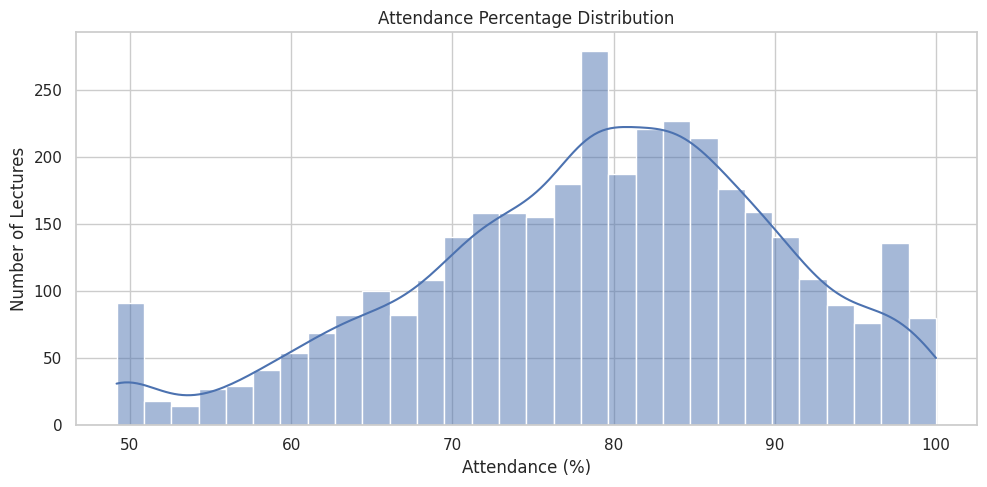

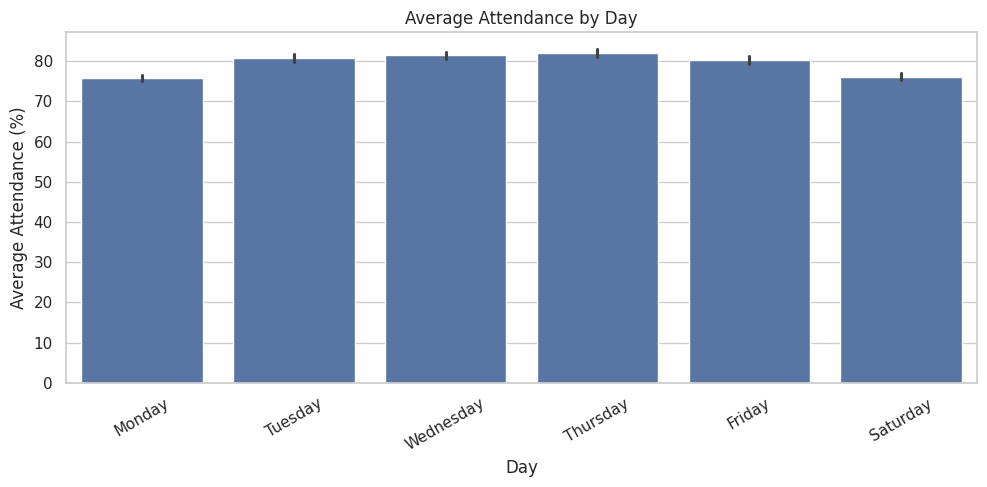

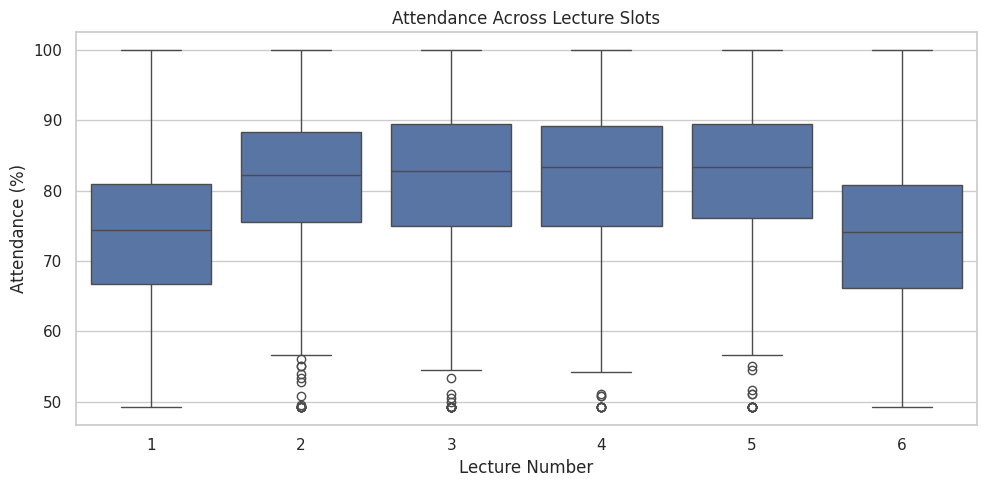

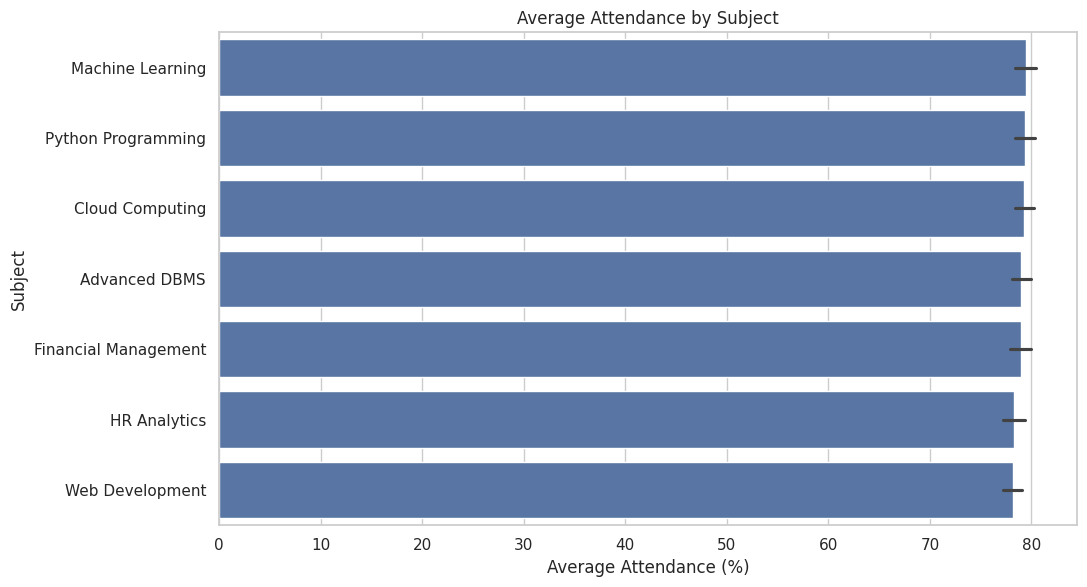

In [45]:
# ============================================================
# CELL 7 — EXPLORATORY DATA ANALYSIS
# ============================================================

# ------------------------------------------------------------
# 1. Attendance Distribution
# ------------------------------------------------------------

plt.figure(figsize=(10, 5))

sns.histplot(
    df["Attendance_Pct"],
    bins=30,
    kde=True
)

plt.title(
    "Attendance Percentage Distribution"
)

plt.xlabel("Attendance (%)")
plt.ylabel("Number of Lectures")

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 2. Attendance by Day
# ------------------------------------------------------------

day_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday"
]

plt.figure(figsize=(10, 5))

sns.barplot(
    data=df,
    x="Day",
    y="Attendance_Pct",
    order=day_order
)

plt.title(
    "Average Attendance by Day"
)

plt.xlabel("Day")
plt.ylabel("Average Attendance (%)")

plt.xticks(rotation=30)

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 3. Attendance by Lecture Slot
# ------------------------------------------------------------

plt.figure(figsize=(10, 5))

sns.boxplot(
    data=df,
    x="Lecture_Number",
    y="Attendance_Pct"
)

plt.title(
    "Attendance Across Lecture Slots"
)

plt.xlabel("Lecture Number")
plt.ylabel("Attendance (%)")

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 4. Subject Attendance
# ------------------------------------------------------------

subject_order = (
    df.groupby("Subject")[
        "Attendance_Pct"
    ]
    .mean()
    .sort_values(
        ascending=False
    )
    .index
)

plt.figure(figsize=(11, 6))

sns.barplot(
    data=df,
    x="Attendance_Pct",
    y="Subject",
    order=subject_order
)

plt.title(
    "Average Attendance by Subject"
)

plt.xlabel("Average Attendance (%)")
plt.ylabel("Subject")

plt.tight_layout()
plt.show()

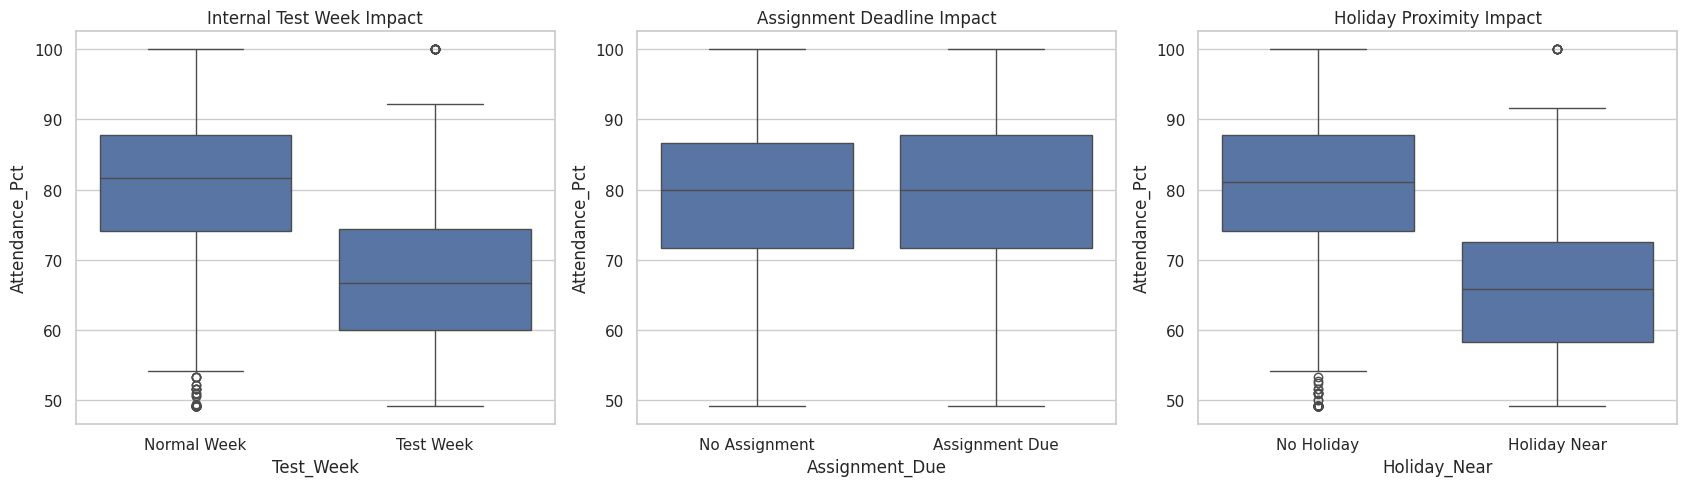

 WELCH TWO-SAMPLE T-TEST
H0: No difference in attendance.
H1: Attendance differs during test weeks.
Test Week Mean : 68.01%
Normal Mean    : 80.52%
Difference     : -12.51 percentage points
T-statistic    : -21.8255
P-value        : 1.76135e-77
Conclusion: Statistically significant difference at α = 0.05.


In [46]:
# ============================================================
# CELL 8 — RISK FACTOR ANALYSIS
# ============================================================

fig, axes = plt.subplots(
    1,
    3,
    figsize=(17, 5)
)

sns.boxplot(
    data=df,
    x="Test_Week",
    y="Attendance_Pct",
    ax=axes[0]
)

axes[0].set_title(
    "Internal Test Week Impact"
)

axes[0].set_xticklabels(
    ["Normal Week", "Test Week"]
)


sns.boxplot(
    data=df,
    x="Assignment_Due",
    y="Attendance_Pct",
    ax=axes[1]
)

axes[1].set_title(
    "Assignment Deadline Impact"
)

axes[1].set_xticklabels(
    ["No Assignment", "Assignment Due"]
)


sns.boxplot(
    data=df,
    x="Holiday_Near",
    y="Attendance_Pct",
    ax=axes[2]
)

axes[2].set_title(
    "Holiday Proximity Impact"
)

axes[2].set_xticklabels(
    ["No Holiday", "Holiday Near"]
)

plt.tight_layout()
plt.show()


# ============================================================
# Statistical Hypothesis Test
# ============================================================

test_attendance = df.loc[
    df["Test_Week"] == 1,
    "Attendance_Pct"
]

normal_attendance = df.loc[
    df["Test_Week"] == 0,
    "Attendance_Pct"
]

t_stat, p_value = stats.ttest_ind(
    test_attendance,
    normal_attendance,
    equal_var=False
)

difference = (
    test_attendance.mean()
    -
    normal_attendance.mean()
)

print("==========================================")
print(" WELCH TWO-SAMPLE T-TEST")
print("==========================================")

print(
    "H0: No difference in attendance."
)

print(
    "H1: Attendance differs during test weeks."
)

print(
    f"Test Week Mean : "
    f"{test_attendance.mean():.2f}%"
)

print(
    f"Normal Mean    : "
    f"{normal_attendance.mean():.2f}%"
)

print(
    f"Difference     : "
    f"{difference:.2f} percentage points"
)

print(
    f"T-statistic    : {t_stat:.4f}"
)

print(
    f"P-value        : {p_value:.6g}"
)

if p_value < 0.05:

    print(
        "Conclusion: Statistically significant "
        "difference at α = 0.05."
    )

else:

    print(
        "Conclusion: No statistically significant "
        "difference at α = 0.05."
    )

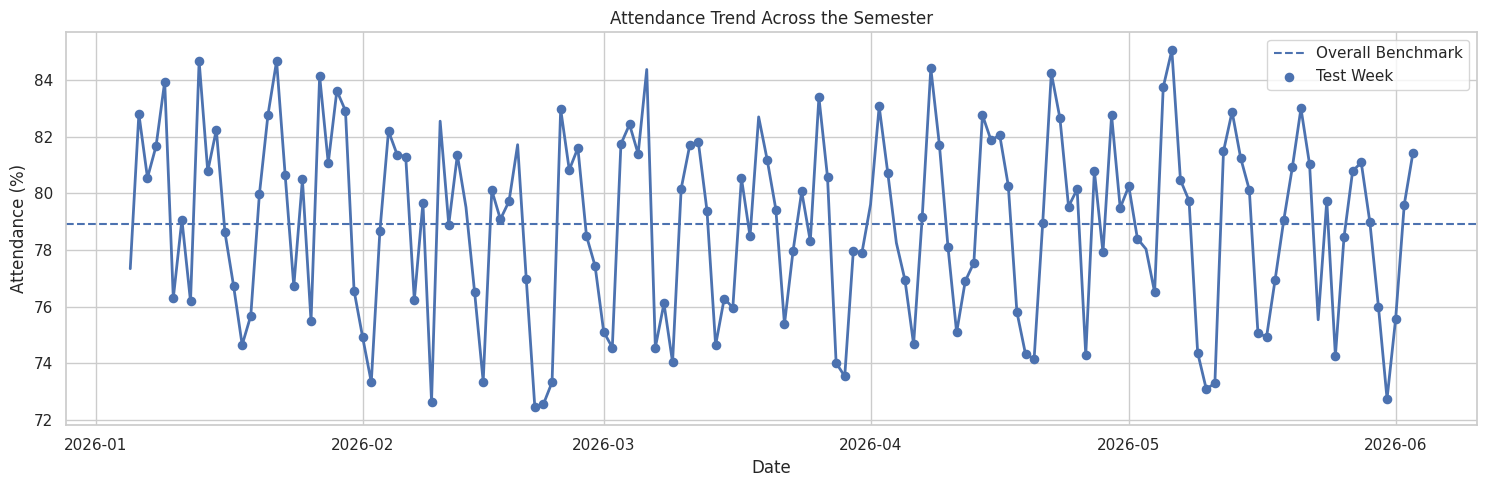

In [47]:
# ============================================================
# CELL 9 — SEMESTER ATTENDANCE TREND
# ============================================================

daily_summary = (
    df.groupby("Date", as_index=False)
      .agg(
          Attendance_Pct=(
              "Attendance_Pct",
              "mean"
          ),
          Test_Week=(
              "Test_Week",
              "max"
          )
      )
)

plt.figure(figsize=(15, 5))

sns.lineplot(
    data=daily_summary,
    x="Date",
    y="Attendance_Pct",
    linewidth=2
)

plt.axhline(
    df["Attendance_Pct"].mean(),
    linestyle="--",
    label="Overall Benchmark"
)

test_points = daily_summary[
    daily_summary["Test_Week"] == 1
]

plt.scatter(
    test_points["Date"],
    test_points["Attendance_Pct"],
    s=35,
    label="Test Week"
)

plt.title(
    "Attendance Trend Across the Semester"
)

plt.xlabel("Date")
plt.ylabel("Attendance (%)")

plt.legend()

plt.tight_layout()
plt.show()

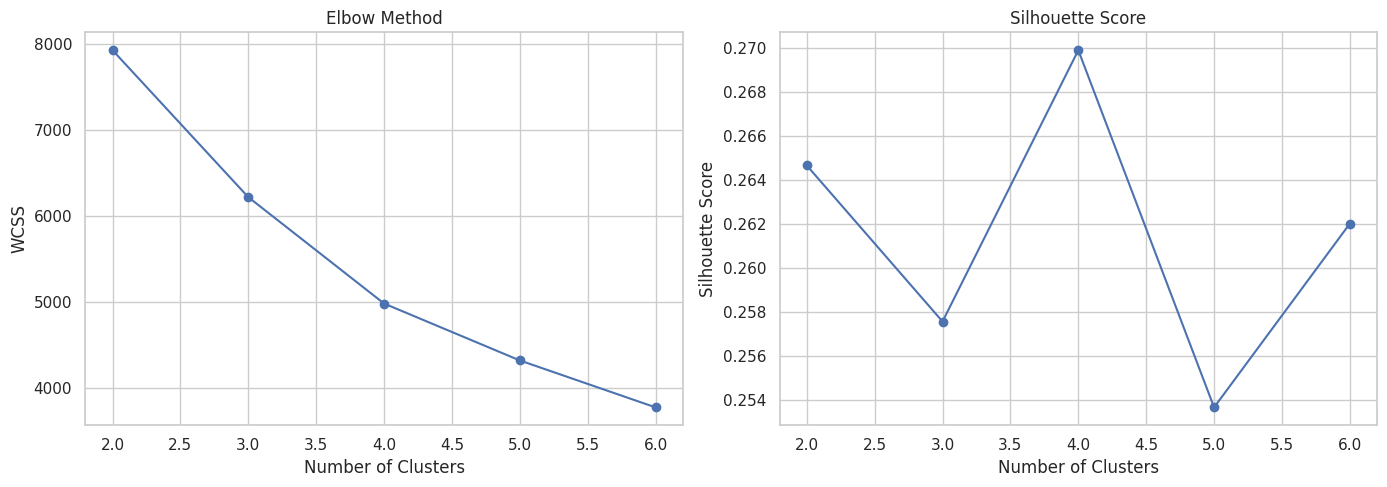

,Average_Attendance,Previous_Attendance,Average_Lecture,Records
Cluster_Profile,,,,
0,75.16,71.87,1.88,1237
1,70.69,79.60,5.30,989
2,88.23,84.76,3.66,1374


In [48]:
# ============================================================
# CELL 10 — K-MEANS ATTENDANCE PROFILES
# ============================================================

cluster_features = [
    "Lecture_Number",
    "Attendance_Pct",
    "Prev_Lecture_Pct"
]

cluster_scaler = StandardScaler()

X_cluster = cluster_scaler.fit_transform(
    df[cluster_features]
)

wcss = []
silhouette_scores = []

K_values = range(2, 7)

for k in K_values:

    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = model.fit_predict(
        X_cluster
    )

    wcss.append(
        model.inertia_
    )

    silhouette_scores.append(
        silhouette_score(
            X_cluster,
            labels
        )
    )


fig, axes = plt.subplots(
    1,
    2,
    figsize=(14, 5)
)

axes[0].plot(
    list(K_values),
    wcss,
    marker="o"
)

axes[0].set_title(
    "Elbow Method"
)

axes[0].set_xlabel(
    "Number of Clusters"
)

axes[0].set_ylabel(
    "WCSS"
)


axes[1].plot(
    list(K_values),
    silhouette_scores,
    marker="o"
)

axes[1].set_title(
    "Silhouette Score"
)

axes[1].set_xlabel(
    "Number of Clusters"
)

axes[1].set_ylabel(
    "Silhouette Score"
)

plt.tight_layout()
plt.show()


# Final clustering

optimal_k = 3

cluster_model = KMeans(
    n_clusters=optimal_k,
    random_state=42,
    n_init=10
)

df["Cluster_Profile"] = (
    cluster_model.fit_predict(
        X_cluster
    )
)

cluster_summary = (
    df.groupby("Cluster_Profile")
      .agg(
          Average_Attendance=(
              "Attendance_Pct",
              "mean"
          ),
          Previous_Attendance=(
              "Prev_Lecture_Pct",
              "mean"
          ),
          Average_Lecture=(
              "Lecture_Number",
              "mean"
          ),
          Records=(
              "Attendance_Pct",
              "size"
          )
      )
      .round(2)
)

display(cluster_summary)

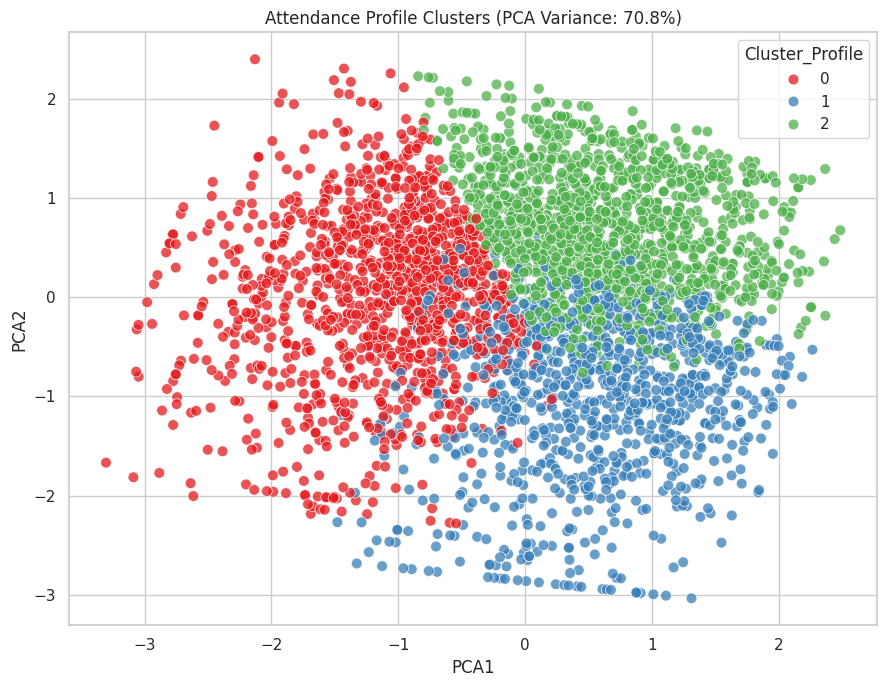

In [49]:
# ============================================================
# CELL 11 — PCA CLUSTER VISUALIZATION
# ============================================================

pca = PCA(
    n_components=2
)

pca_data = pca.fit_transform(
    X_cluster
)

df["PCA1"] = pca_data[:, 0]
df["PCA2"] = pca_data[:, 1]

plt.figure(figsize=(9, 7))

sns.scatterplot(
    data=df,
    x="PCA1",
    y="PCA2",
    hue="Cluster_Profile",
    palette="Set1",
    s=60,
    alpha=0.75
)

variance = (
    pca.explained_variance_ratio_.sum()
    * 100
)

plt.title(
    f"Attendance Profile Clusters "
    f"(PCA Variance: {variance:.1f}%)"
)

plt.tight_layout()
plt.show()

In [50]:
# ============================================================
# CELL 12 — TARGETS, FEATURES & TRAIN/TEST SPLIT
# ============================================================

categorical_features = [
    "Day",
    "Subject",
    "Faculty_ID",
    "Branch",
    "Session_Type",
    "Time_of_Day",
    "Classroom"
]

numerical_features = [
    "Lecture_Number",
    "Total_Enrolled",
    "Test_Week",
    "Assignment_Due",
    "Holiday_Near",
    "Prev_Lecture_Pct",
    "Rolling_3_Avg",
    "Rolling_7_Avg",
    "Gap_Hours",
    "Day_of_Semester",
    "Week_Number",
    "Consecutive_Lecture_Count",
    "Monthly_Avg_Attendance"
]

model_features = (
    numerical_features
    +
    categorical_features
)

# ------------------------------------------------------------
# Classification target
# ------------------------------------------------------------

df["Attendance_Band"] = pd.cut(
    df["Attendance_Pct"],
    bins=[
        -0.01,
        50,
        75,
        100
    ],
    labels=[
        "Low (<50%)",
        "Medium (50-75%)",
        "High (>75%)"
    ]
)

df["Attendance_Band_Code"] = (
    df["Attendance_Band"]
    .cat.codes
)

X = df[
    model_features
].copy()

y_reg = df[
    "Attendance_Pct"
].copy()

y_cls = df[
    "Attendance_Band_Code"
].copy()


# ------------------------------------------------------------
# Train/Test split
# ------------------------------------------------------------

X_train, X_test, y_train_reg, y_test_reg, y_train_cls, y_test_cls = train_test_split(
    X,
    y_reg,
    y_cls,
    test_size=0.20,
    random_state=42,
    stratify=y_cls
)


# ------------------------------------------------------------
# Preprocessor
# ------------------------------------------------------------

preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            Pipeline([
                (
                    "imputer",
                    SimpleImputer(
                        strategy="median"
                    )
                ),
                (
                    "scaler",
                    StandardScaler()
                )
            ]),
            numerical_features
        ),

        (
            "cat",
            Pipeline([
                (
                    "imputer",
                    SimpleImputer(
                        strategy="most_frequent"
                    )
                ),
                (
                    "onehot",
                    OneHotEncoder(
                        handle_unknown="ignore",
                        drop="first",
                        sparse_output=False
                    )
                )
            ]),
            categorical_features
        )
    ]
)

print(
    f"Training records: {len(X_train):,}"
)

print(
    f"Testing records : {len(X_test):,}"
)

Training records: 2,880
Testing records : 720


In [51]:
# ============================================================
# CELL 13 — REGRESSION MODEL COMPARISON
# ============================================================

regressors = {

    "Ridge Regression":
        Ridge(alpha=1.0),

    "Random Forest":
        RandomForestRegressor(
            n_estimators=150,
            max_depth=12,
            random_state=42,
            n_jobs=-1
        ),

    "Gradient Boosting":
        GradientBoostingRegressor(
            n_estimators=150,
            learning_rate=0.06,
            random_state=42
        ),

    "XGBoost Regressor":
        XGBRegressor(
            n_estimators=150,
            learning_rate=0.06,
            max_depth=5,
            random_state=42,
            n_jobs=-1
        )
}

regression_results = []
regression_pipelines = {}

for name, model in regressors.items():

    pipeline = Pipeline([
        (
            "preprocessor",
            preprocessor
        ),
        (
            "model",
            model
        )
    ])

    pipeline.fit(
        X_train,
        y_train_reg
    )

    predictions = pipeline.predict(
        X_test
    )

    regression_pipelines[name] = pipeline

    mae = mean_absolute_error(
        y_test_reg,
        predictions
    )

    rmse = np.sqrt(
        mean_squared_error(
            y_test_reg,
            predictions
        )
    )

    mape = (
        mean_absolute_percentage_error(
            y_test_reg,
            predictions
        )
        * 100
    )

    r2 = r2_score(
        y_test_reg,
        predictions
    )

    regression_results.append({
        "Algorithm": name,
        "MAE (%)": mae,
        "RMSE (%)": rmse,
        "MAPE (%)": mape,
        "R2 Score": r2
    })


df_reg_eval = pd.DataFrame(
    regression_results
)

df_reg_eval = (
    df_reg_eval
    .sort_values(
        "RMSE (%)"
    )
    .reset_index(drop=True)
)

display(
    df_reg_eval.round(4)
)

best_reg_name = (
    df_reg_eval.iloc[0]["Algorithm"]
)

best_reg = (
    regression_pipelines[
        best_reg_name
    ]
)

print(
    f"Best regression model: "
    f"{best_reg_name}"
)

,Algorithm,MAE (%),RMSE (%),MAPE (%),R2 Score
0,Gradient Boosting,6.3405,8.4760,8.5571,0.4769
1,XGBoost Regressor,6.3977,8.5096,8.6221,0.4728
2,Random Forest,6.5486,8.6779,8.8421,0.4517
3,Ridge Regression,6.9921,9.1344,9.4049,0.3925


Best regression model: Gradient Boosting


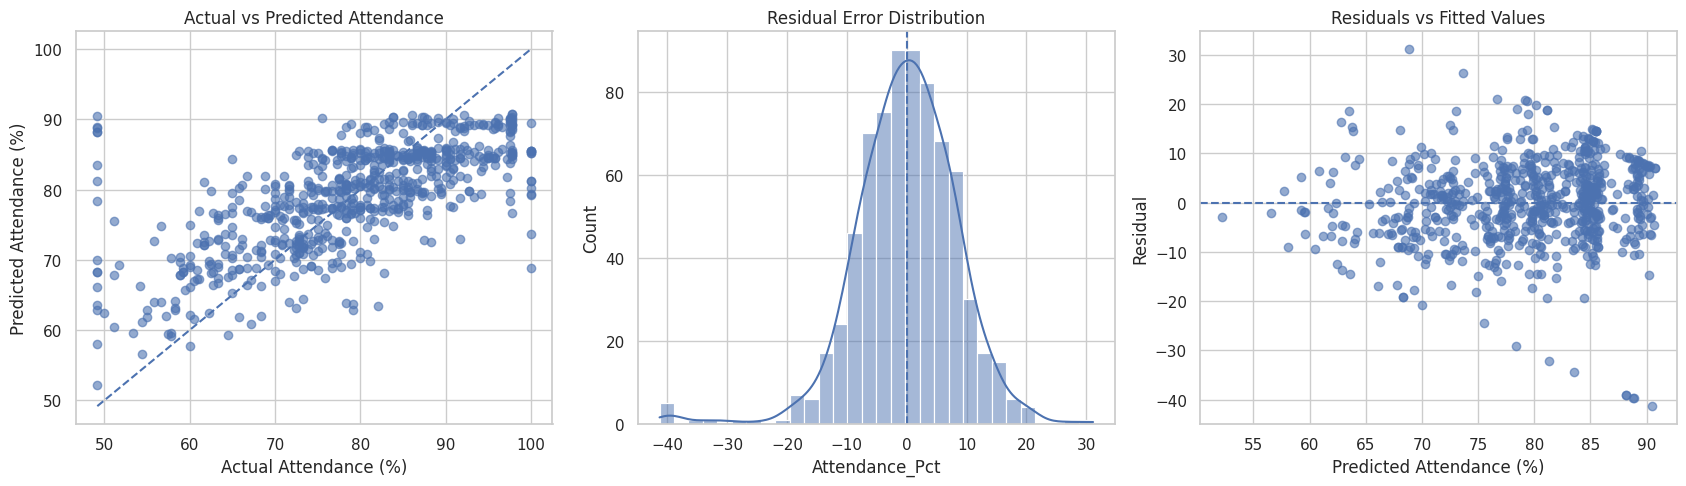

In [52]:
# ============================================================
# CELL 14 — REGRESSION DIAGNOSTICS
# ============================================================

predictions = best_reg.predict(
    X_test
)

residuals = (
    y_test_reg
    - predictions
)

fig, axes = plt.subplots(
    1,
    3,
    figsize=(17, 5)
)

# Actual vs predicted

axes[0].scatter(
    y_test_reg,
    predictions,
    alpha=0.6
)

minimum = min(
    y_test_reg.min(),
    predictions.min()
)

maximum = max(
    y_test_reg.max(),
    predictions.max()
)

axes[0].plot(
    [minimum, maximum],
    [minimum, maximum],
    "--"
)

axes[0].set_title(
    "Actual vs Predicted Attendance"
)

axes[0].set_xlabel(
    "Actual Attendance (%)"
)

axes[0].set_ylabel(
    "Predicted Attendance (%)"
)


# Residual distribution

sns.histplot(
    residuals,
    bins=30,
    kde=True,
    ax=axes[1]
)

axes[1].axvline(
    0,
    linestyle="--"
)

axes[1].set_title(
    "Residual Error Distribution"
)


# Residual vs fitted

axes[2].scatter(
    predictions,
    residuals,
    alpha=0.6
)

axes[2].axhline(
    0,
    linestyle="--"
)

axes[2].set_title(
    "Residuals vs Fitted Values"
)

axes[2].set_xlabel(
    "Predicted Attendance (%)"
)

axes[2].set_ylabel(
    "Residual"
)

plt.tight_layout()
plt.show()

In [53]:
# ============================================================
# CELL 15 — CLASSIFICATION MODEL COMPARISON
# ============================================================

classifiers = {

    "Logistic Regression":
        LogisticRegression(
            max_iter=1500
        ),

    "k-Nearest Neighbors":
        KNeighborsClassifier(
            n_neighbors=7
        ),

    "Support Vector Machine":
        SVC(
            kernel="rbf",
            probability=True,
            random_state=42
        ),

    "XGBoost Classifier":
        XGBClassifier(
            n_estimators=150,
            learning_rate=0.06,
            max_depth=5,
            random_state=42,
            n_jobs=-1
        )
}

classification_results = []
classification_pipelines = {}

for name, model in classifiers.items():

    pipeline = Pipeline([
        (
            "preprocessor",
            preprocessor
        ),
        (
            "model",
            model
        )
    ])

    pipeline.fit(
        X_train,
        y_train_cls
    )

    predictions = pipeline.predict(
        X_test
    )

    probabilities = pipeline.predict_proba(
        X_test
    )

    accuracy = (
        accuracy_score(
            y_test_cls,
            predictions
        )
        * 100
    )

    precision = precision_score(
        y_test_cls,
        predictions,
        average="weighted",
        zero_division=0
    )

    recall = recall_score(
        y_test_cls,
        predictions,
        average="weighted",
        zero_division=0
    )

    f1 = f1_score(
        y_test_cls,
        predictions,
        average="weighted",
        zero_division=0
    )

    roc_auc = roc_auc_score(
        y_test_cls,
        probabilities,
        multi_class="ovr",
        average="weighted"
    )

    classification_pipelines[name] = pipeline

    classification_results.append({

        "Classifier": name,

        "Accuracy (%)":
            accuracy,

        "Precision":
            precision,

        "Recall":
            recall,

        "F1-Score":
            f1,

        "ROC-AUC":
            roc_auc
    })


df_cls_eval = pd.DataFrame(
    classification_results
)

df_cls_eval = (
    df_cls_eval
    .sort_values(
        "F1-Score",
        ascending=False
    )
    .reset_index(drop=True)
)

display(
    df_cls_eval.round(4)
)

best_cls_name = (
    df_cls_eval.iloc[0]["Classifier"]
)

best_cls = (
    classification_pipelines[
        best_cls_name
    ]
)

print(
    f"Best classification model: "
    f"{best_cls_name}"
)

,Classifier,Accuracy (%),Precision,Recall,F1-Score,ROC-AUC
0,XGBoost Classifier,80.9722,0.8111,0.8097,0.7997,0.8695
1,Support Vector Machine,78.1944,0.7601,0.7819,0.7601,0.8333
2,k-Nearest Neighbors,76.1111,0.7486,0.7611,0.7476,0.7822
3,Logistic Regression,76.6667,0.7427,0.7667,0.7439,0.8143


Best classification model: XGBoost Classifier


                 precision    recall  f1-score   support

     Low (<50%)       1.00      0.06      0.11        17
Medium (50-75%)       0.74      0.69      0.71       231
    High (>75%)       0.84      0.90      0.87       472

       accuracy                           0.81       720
      macro avg       0.86      0.55      0.56       720
   weighted avg       0.81      0.81      0.80       720



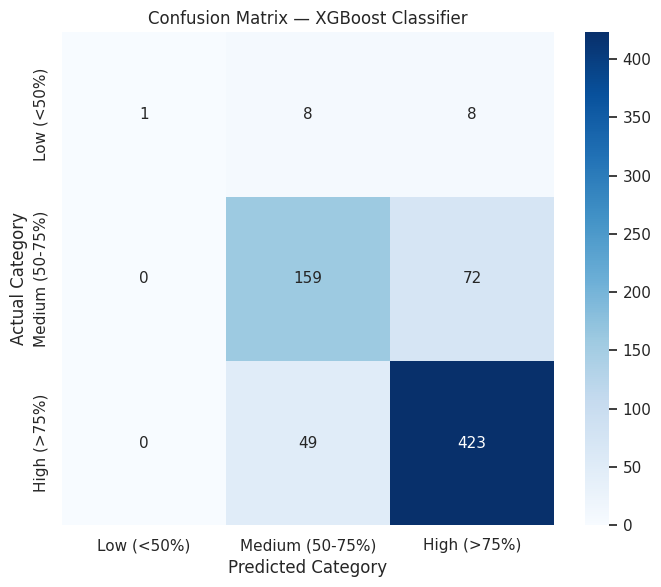

In [54]:
# ============================================================
# CELL 16 — CONFUSION MATRIX
# ============================================================

band_labels = [
    "Low (<50%)",
    "Medium (50-75%)",
    "High (>75%)"
]

predictions = best_cls.predict(
    X_test
)

print(
    classification_report(
        y_test_cls,
        predictions,
        target_names=band_labels,
        zero_division=0
    )
)

cm = confusion_matrix(
    y_test_cls,
    predictions
)

plt.figure(
    figsize=(7, 6)
)

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=band_labels,
    yticklabels=band_labels
)

plt.title(
    f"Confusion Matrix — {best_cls_name}"
)

plt.xlabel(
    "Predicted Category"
)

plt.ylabel(
    "Actual Category"
)

plt.tight_layout()
plt.show()

Best parameters:
{'model__n_estimators': 250, 'model__min_samples_split': 5, 'model__max_depth': 12}
Tuned RF RMSE: 8.691%


,Feature,Importance
4,Holiday_Near,0.189090
2,Test_Week,0.148138
0,Lecture_Number,0.141743
7,Rolling_7_Avg,0.059935
6,Rolling_3_Avg,0.057603
12,Monthly_Avg_Attendance,0.057452
5,Prev_Lecture_Pct,0.050160
30,Session_Type_Theory,0.045627
9,Day_of_Semester,0.035385
13,Day_Monday,0.032407


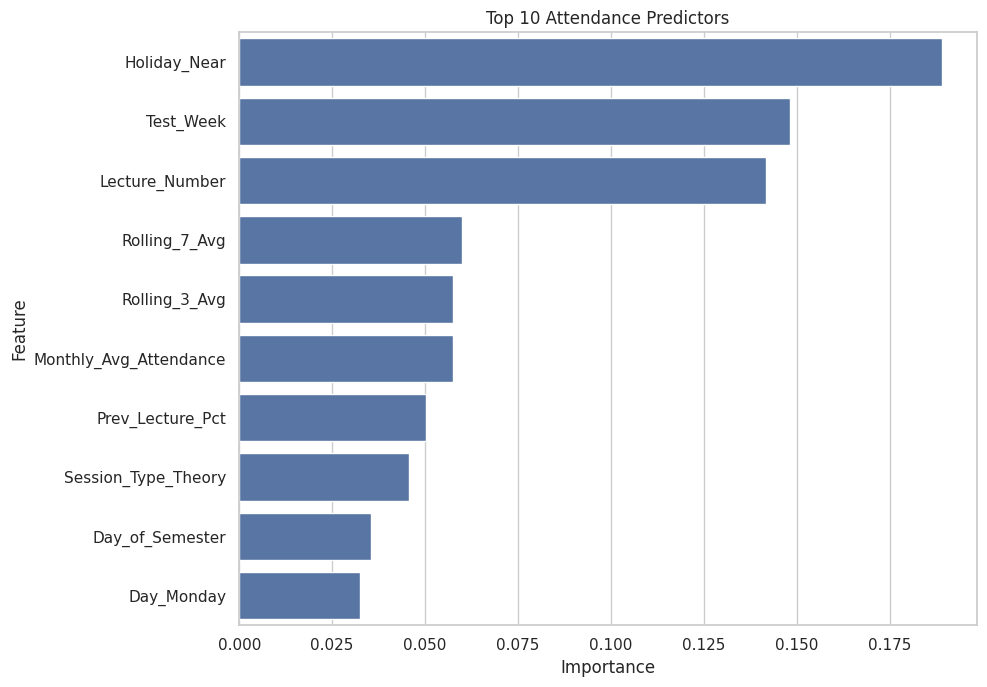

In [55]:
# ============================================================
# CELL 17 — HYPERPARAMETER TUNING
# ============================================================

rf_pipeline = Pipeline([
    (
        "preprocessor",
        preprocessor
    ),
    (
        "model",
        RandomForestRegressor(
            random_state=42,
            n_jobs=-1
        )
    )
])

parameter_grid = {

    "model__n_estimators":
        [100, 150, 200, 250],

    "model__max_depth":
        [8, 12, 16, None],

    "model__min_samples_split":
        [2, 5, 10]
}

rf_search = RandomizedSearchCV(

    rf_pipeline,

    parameter_grid,

    n_iter=8,

    cv=3,

    scoring="neg_root_mean_squared_error",

    random_state=42,

    n_jobs=-1
)

rf_search.fit(
    X_train,
    y_train_reg
)

tuned_rf = (
    rf_search.best_estimator_
)

tuned_predictions = (
    tuned_rf.predict(
        X_test
    )
)

print(
    "Best parameters:"
)

print(
    rf_search.best_params_
)

print(
    f"Tuned RF RMSE: "
    f"{np.sqrt(mean_squared_error(y_test_reg, tuned_predictions)):.3f}%"
)


# ============================================================
# FEATURE IMPORTANCE
# ============================================================

rf_model = (
    tuned_rf
    .named_steps["model"]
)

rf_preprocessor = (
    tuned_rf
    .named_steps["preprocessor"]
)

encoded_names = (
    rf_preprocessor
    .named_transformers_["cat"]
    .named_steps["onehot"]
    .get_feature_names_out(
        categorical_features
    )
)

all_feature_names = (
    numerical_features
    +
    list(encoded_names)
)

importance_df = pd.DataFrame({

    "Feature":
        all_feature_names,

    "Importance":
        rf_model.feature_importances_

})

importance_df = (
    importance_df
    .sort_values(
        "Importance",
        ascending=False
    )
)

display(
    importance_df.head(15)
)

plt.figure(
    figsize=(10, 7)
)

sns.barplot(
    data=importance_df.head(10),
    x="Importance",
    y="Feature"
)

plt.title(
    "Top 10 Attendance Predictors"
)

plt.tight_layout()
plt.show()

In [56]:
# ============================================================
# CELL 18 — SAVE DEPLOYMENT MODEL
# ============================================================

deployment_package = {

    "regression_model":
        best_reg,

    "classification_model":
        best_cls,

    "band_labels":
        band_labels,

    "model_features":
        model_features,

    "numerical_features":
        numerical_features,

    "categorical_features":
        categorical_features,

    "metadata": {

        "created_on":
            datetime.now().strftime(
                "%Y-%m-%d %H:%M:%S"
            ),

        "regression_model":
            best_reg_name,

        "classification_model":
            best_cls_name,

        "dataset_rows":
            int(len(df))
    }
}

MODEL_FILE = (
    "imcc_attendance_ml_pipeline.pkl"
)

joblib.dump(
    deployment_package,
    MODEL_FILE
)

print(
    f"Model saved successfully: "
    f"{MODEL_FILE}"
)

Model saved successfully: imcc_attendance_ml_pipeline.pkl


In [57]:
# ============================================================
# CELL 18 — SAVE DEPLOYMENT MODEL
# ============================================================

deployment_package = {

    "regression_model":
        best_reg,

    "classification_model":
        best_cls,

    "band_labels":
        band_labels,

    "model_features":
        model_features,

    "numerical_features":
        numerical_features,

    "categorical_features":
        categorical_features,

    "metadata": {

        "created_on":
            datetime.now().strftime(
                "%Y-%m-%d %H:%M:%S"
            ),

        "regression_model":
            best_reg_name,

        "classification_model":
            best_cls_name,

        "dataset_rows":
            int(len(df))
    }
}

MODEL_FILE = (
    "imcc_attendance_ml_pipeline.pkl"
)

joblib.dump(
    deployment_package,
    MODEL_FILE
)

print(
    f"Model saved successfully: "
    f"{MODEL_FILE}"
)

Model saved successfully: imcc_attendance_ml_pipeline.pkl


In [58]:
# ============================================================
# CELL 19 — STREAMLIT
# ============================================================

!pip install -q streamlit xgboost joblib

In [59]:
%%writefile app.py

import os
import joblib
import numpy as np
import pandas as pd
import streamlit as st
import matplotlib.pyplot as plt
import seaborn as sns

from datetime import datetime


# ============================================================
# PAGE CONFIG
# ============================================================

st.set_page_config(
    page_title="IMCC Attendance Intelligence",
    page_icon="🎓",
    layout="wide"
)

sns.set_theme(
    style="whitegrid"
)


# ============================================================
# FILES
# ============================================================

MODEL_FILE = (
    "imcc_attendance_ml_pipeline.pkl"
)

DATA_FILE = (
    "imcc_cleaned_attendance.csv"
)


# ============================================================
# LOAD MODEL
# ============================================================

@st.cache_resource
def load_model():

    return joblib.load(
        MODEL_FILE
    )


# ============================================================
# LOAD HISTORY
# ============================================================

@st.cache_data
def load_history():

    if not os.path.exists(
        DATA_FILE
    ):

        return pd.DataFrame()

    data = pd.read_csv(
        DATA_FILE
    )

    data["Date"] = pd.to_datetime(
        data["Date"],
        errors="coerce"
    )

    return data


if not os.path.exists(
    MODEL_FILE
):

    st.error(
        "Model file not found. "
        "Run the notebook training cells first."
    )

    st.stop()


assets = load_model()

history = load_history()

reg_model = (
    assets["regression_model"]
)

cls_model = (
    assets["classification_model"]
)

band_labels = (
    assets["band_labels"]
)


# ============================================================
# HEADER
# ============================================================

st.title(
    "🎓 IMCC Attendance Intelligence Dashboard"
)

st.markdown(
    """
    **AI-powered future lecture attendance prediction
    and historical attendance analytics.**
    """
)


# ============================================================
# SIDEBAR
# ============================================================

st.sidebar.header(
    "🔮 Prediction Inputs"
)


selected_date = st.sidebar.date_input(
    "Lecture Date",
    datetime.today().date()
)


lecture_number = st.sidebar.selectbox(
    "Lecture Slot",
    [1, 2, 3, 4, 5, 6]
)


# Branch

branches = (
    sorted(
        history["Branch"]
        .dropna()
        .unique()
    )
    if not history.empty
    else ["MCA", "MBA"]
)

branch = st.sidebar.selectbox(
    "Academic Branch",
    branches
)


# Section

section_data = (
    history[
        history["Branch"] == branch
    ]
    if not history.empty
    else pd.DataFrame()
)

sections = (
    sorted(
        section_data["Section"]
        .dropna()
        .unique()
    )
    if not section_data.empty
    else ["A", "B", "C"]
)

section = st.sidebar.selectbox(
    "Section",
    sections
)


# Subject

subject_data = (
    history[
        history["Branch"] == branch
    ]
    if not history.empty
    else pd.DataFrame()
)

subjects = (
    sorted(
        subject_data["Subject"]
        .dropna()
        .unique()
    )
    if not subject_data.empty
    else ["Python Programming"]
)

subject = st.sidebar.selectbox(
    "Subject",
    subjects
)


# Faculty

faculties = (
    sorted(
        subject_data["Faculty_ID"]
        .dropna()
        .unique()
    )
    if not subject_data.empty
    else ["Faculty"]
)

faculty = st.sidebar.selectbox(
    "Faculty",
    faculties
)


# Classroom

classrooms = (
    sorted(
        subject_data["Classroom"]
        .dropna()
        .unique()
    )
    if not subject_data.empty
    else ["Room 201"]
)

classroom = st.sidebar.selectbox(
    "Classroom",
    classrooms
)


session_type = (
    "Practical"
    if "Lab" in classroom
    else "Theory"
)


# Enrollment

if not subject_data.empty:

    enrollment_default = int(
        subject_data[
            "Total_Enrolled"
        ].median()
    )

else:

    enrollment_default = (
        180
        if branch == "MCA"
        else 120
    )


total_enrolled = st.sidebar.number_input(
    "Total Enrolled",
    min_value=1,
    value=enrollment_default
)


# Previous attendance

previous_attendance = st.sidebar.slider(
    "Previous Lecture Attendance (%)",
    0.0,
    100.0,
    80.0,
    0.5
)


test_week = int(
    st.sidebar.checkbox(
        "Internal Test Week"
    )
)


assignment_due = int(
    st.sidebar.checkbox(
        "Assignment Due"
    )
)


holiday_near = int(
    st.sidebar.checkbox(
        "Holiday Near"
    )
)


# ============================================================
# HISTORICAL FEATURES
# ============================================================

if not history.empty:

    historical = history[
        (history["Branch"] == branch)
        &
        (history["Section"] == section)
        &
        (history["Subject"] == subject)
        &
        (
            history["Date"]
            <
            pd.Timestamp(
                selected_date
            )
        )
    ].sort_values(
        ["Date", "Lecture_Number"]
    )

else:

    historical = pd.DataFrame()


if not historical.empty:

    rolling_3 = float(
        historical[
            "Attendance_Pct"
        ]
        .tail(3)
        .mean()
    )

    rolling_7 = float(
        historical[
            "Attendance_Pct"
        ]
        .tail(7)
        .mean()
    )

    previous_from_history = float(
        historical[
            "Attendance_Pct"
        ].iloc[-1]
    )

    monthly_average = float(
        historical[
            "Attendance_Pct"
        ].mean()
    )

else:

    rolling_3 = previous_attendance
    rolling_7 = previous_attendance
    previous_from_history = previous_attendance
    monthly_average = previous_attendance


# ============================================================
# DATE FEATURES
# ============================================================

start_times = {

    1: "09:00 AM",
    2: "10:00 AM",
    3: "11:15 AM",
    4: "12:15 PM",
    5: "02:00 PM",
    6: "03:00 PM"

}

start_time = (
    start_times[
        lecture_number
    ]
)

day_name = (
    pd.Timestamp(
        selected_date
    ).day_name()
)

time_of_day = (
    "Morning"
    if "AM" in start_time
    else "Afternoon"
)


# ============================================================
# TEMPORAL FEATURES
# ============================================================

if not history.empty:

    semester_start = (
        history["Date"].min()
    )

    day_of_semester = (
        pd.Timestamp(
            selected_date
        )
        - semester_start
    ).days + 1

else:

    day_of_semester = 1


week_number = max(
    1,
    (
        day_of_semester - 1
    ) // 7 + 1
)


# ============================================================
# GAP
# ============================================================

lecture_datetime = pd.Timestamp(
    f"{selected_date} {start_time}"
)

if not historical.empty:

    last_datetime = pd.Timestamp(
        historical["Date"].iloc[-1]
    )

    gap_hours = (
        lecture_datetime
        - last_datetime
    ).total_seconds() / 3600

    if gap_hours <= 0:

        gap_hours = 24

else:

    gap_hours = 24


# ============================================================
# PREDICTION
# ============================================================

st.divider()


if st.button(
    "🔮 Generate Attendance Prediction",
    type="primary",
    use_container_width=True
):

    input_data = pd.DataFrame({

        "Lecture_Number":
            [lecture_number],

        "Total_Enrolled":
            [total_enrolled],

        "Test_Week":
            [test_week],

        "Assignment_Due":
            [assignment_due],

        "Holiday_Near":
            [holiday_near],

        "Prev_Lecture_Pct":
            [previous_attendance],

        "Rolling_3_Avg":
            [rolling_3],

        "Rolling_7_Avg":
            [rolling_7],

        "Gap_Hours":
            [gap_hours],

        "Day_of_Semester":
            [day_of_semester],

        "Week_Number":
            [week_number],

        "Consecutive_Lecture_Count":
            [lecture_number],

        "Monthly_Avg_Attendance":
            [monthly_average],

        "Day":
            [day_name],

        "Subject":
            [subject],

        "Faculty_ID":
            [faculty],

        "Branch":
            [branch],

        "Session_Type":
            [session_type],

        "Time_of_Day":
            [time_of_day],

        "Classroom":
            [classroom]
    })


    # Prediction

    predicted_attendance = float(
        np.clip(
            reg_model.predict(
                input_data
            )[0],
            0,
            100
        )
    )


    predicted_class = int(
        cls_model.predict(
            input_data
        )[0]
    )


    predicted_band = (
        band_labels[
            predicted_class
        ]
    )


    expected_students = int(
        round(
            total_enrolled
            *
            predicted_attendance
            / 100
        )
    )


    # ========================================================
    # KPI CARDS
    # ========================================================

    st.subheader(
        "📌 Prediction Summary"
    )

    c1, c2, c3, c4 = st.columns(4)

    c1.metric(
        "Predicted Attendance",
        f"{predicted_attendance:.1f}%"
    )

    c2.metric(
        "Expected Students",
        f"{expected_students}"
    )

    c3.metric(
        "Class Strength",
        f"{total_enrolled}"
    )

    c4.metric(
        "Attendance Band",
        predicted_band
    )


    # ========================================================
    # RISK
    # ========================================================

    if "Low" in predicted_band:

        st.error(
            "🚨 HIGH RISK: "
            "Predicted attendance is below 50%."
        )

    elif "Medium" in predicted_band:

        st.warning(
            "⚠️ MODERATE RISK: "
            "Predicted attendance is between 50% and 75%."
        )

    else:

        st.success(
            "✅ GOOD OUTLOOK: "
            "Predicted attendance is above 75%."
        )


    # ========================================================
    # GRAPH 1
    # ========================================================

    st.subheader(
        "📊 Previous vs Predicted Attendance"
    )

    fig, ax = plt.subplots(
        figsize=(9, 4)
    )

    values = [
        previous_attendance,
        predicted_attendance
    ]

    bars = ax.bar(
        [
            "Previous Lecture",
            "Predicted Lecture"
        ],
        values
    )

    ax.set_ylim(
        0,
        100
    )

    ax.set_ylabel(
        "Attendance (%)"
    )

    ax.set_title(
        "Attendance Prediction Comparison"
    )

    for bar, value in zip(
        bars,
        values
    ):

        ax.text(
            bar.get_x()
            + bar.get_width()/2,
            value + 2,
            f"{value:.1f}%",
            ha="center"
        )

    st.pyplot(
        fig,
        use_container_width=True
    )

    plt.close(fig)


    # ========================================================
    # GRAPH 2 — PRESENT VS ABSENT
    # ========================================================

    st.subheader(
        "👥 Expected Classroom Strength"
    )

    fig, ax = plt.subplots(
        figsize=(9, 4)
    )

    present = expected_students

    absent = (
        total_enrolled
        - expected_students
    )

    ax.bar(
        ["Expected Present", "Expected Absent"],
        [present, absent]
    )

    ax.set_ylabel(
        "Students"
    )

    ax.set_title(
        "Expected Student Distribution"
    )

    st.pyplot(
        fig,
        use_container_width=True
    )

    plt.close(fig)


# ============================================================
# HISTORICAL ANALYTICS
# ============================================================

if not history.empty:

    st.divider()

    st.header(
        "📊 Historical Attendance Analytics"
    )


    # ========================================================
    # GRAPH 3 — DAY
    # ========================================================

    col1, col2 = st.columns(2)

    with col1:

        day_summary = (
            history
            .groupby("Day", as_index=False)
            ["Attendance_Pct"]
            .mean()
        )

        day_order = [
            "Monday",
            "Tuesday",
            "Wednesday",
            "Thursday",
            "Friday",
            "Saturday",
            "Sunday"
        ]

        day_summary["Order"] = (
            day_summary["Day"]
            .map(
                {
                    day: index
                    for index, day
                    in enumerate(day_order)
                }
            )
        )

        day_summary = (
            day_summary
            .sort_values("Order")
        )

        fig, ax = plt.subplots(
            figsize=(8, 4)
        )

        sns.barplot(
            data=day_summary,
            x="Day",
            y="Attendance_Pct",
            ax=ax
        )

        ax.set_ylim(
            0,
            100
        )

        ax.set_title(
            "Average Attendance by Day"
        )

        ax.set_ylabel(
            "Attendance (%)"
        )

        ax.tick_params(
            axis="x",
            rotation=30
        )

        st.pyplot(
            fig,
            use_container_width=True
        )

        plt.close(fig)


    # ========================================================
    # GRAPH 4 — LECTURE SLOT
    # ========================================================

    with col2:

        slot_summary = (
            history
            .groupby(
                "Lecture_Number",
                as_index=False
            )["Attendance_Pct"]
            .mean()
        )

        fig, ax = plt.subplots(
            figsize=(8, 4)
        )

        sns.lineplot(
            data=slot_summary,
            x="Lecture_Number",
            y="Attendance_Pct",
            marker="o",
            linewidth=2,
            ax=ax
        )

        ax.set_ylim(
            0,
            100
        )

        ax.set_title(
            "Attendance by Lecture Slot"
        )

        ax.set_ylabel(
            "Attendance (%)"
        )

        ax.set_xlabel(
            "Lecture Number"
        )

        st.pyplot(
            fig,
            use_container_width=True
        )

        plt.close(fig)


    # ========================================================
    # GRAPH 5 — SUBJECT
    # ========================================================

    st.subheader(
        "📚 Attendance by Subject"
    )

    subject_summary = (
        history
        .groupby(
            "Subject",
            as_index=False
        )["Attendance_Pct"]
        .mean()
        .sort_values(
            "Attendance_Pct",
            ascending=False
        )
    )

    fig, ax = plt.subplots(
        figsize=(12, 6)
    )

    sns.barplot(
        data=subject_summary,
        x="Attendance_Pct",
        y="Subject",
        ax=ax
    )

    ax.set_xlim(
        0,
        100
    )

    ax.set_title(
        "Average Attendance by Subject"
    )

    ax.set_xlabel(
        "Attendance (%)"
    )

    st.pyplot(
        fig,
        use_container_width=True
    )

    plt.close(fig)


    # ========================================================
    # GRAPH 6 — TREND
    # ========================================================

    st.subheader(
        "📈 Attendance Trend"
    )

    daily = (
        history
        .groupby(
            "Date",
            as_index=False
        )["Attendance_Pct"]
        .mean()
    )

    fig, ax = plt.subplots(
        figsize=(14, 5)
    )

    ax.plot(
        daily["Date"],
        daily["Attendance_Pct"],
        linewidth=2
    )

    ax.axhline(
        history[
            "Attendance_Pct"
        ].mean(),
        linestyle="--",
        label="Overall Benchmark"
    )

    ax.set_ylim(
        0,
        100
    )

    ax.set_title(
        "Daily Attendance Trend"
    )

    ax.set_xlabel(
        "Date"
    )

    ax.set_ylabel(
        "Attendance (%)"
    )

    ax.legend()

    st.pyplot(
        fig,
        use_container_width=True
    )

    plt.close(fig)


    # ========================================================
    # GRAPH 7 — TEST WEEK
    # ========================================================

    st.subheader(
        "📝 Internal Test Impact"
    )

    test_summary = (
        history
        .groupby(
            "Test_Week",
            as_index=False
        )["Attendance_Pct"]
        .mean()
    )

    test_summary["Period"] = (
        test_summary[
            "Test_Week"
        ].map(
            {
                0: "Normal Week",
                1: "Test Week"
            }
        )
    )

    fig, ax = plt.subplots(
        figsize=(8, 4)
    )

    sns.barplot(
        data=test_summary,
        x="Period",
        y="Attendance_Pct",
        ax=ax
    )

    ax.set_ylim(
        0,
        100
    )

    ax.set_title(
        "Normal Week vs Internal Test Week"
    )

    ax.set_ylabel(
        "Attendance (%)"
    )

    st.pyplot(
        fig,
        use_container_width=True
    )

    plt.close(fig)


    # ========================================================
    # LOW ATTENDANCE SUBJECTS
    # ========================================================

    st.subheader(
        "⚠️ Subjects Requiring Attention"
    )

    low_subjects = (
        subject_summary[
            subject_summary[
                "Attendance_Pct"
            ] < 75
        ]
    )

    if not low_subjects.empty:

        st.dataframe(
            low_subjects
            .style
            .format(
                {
                    "Attendance_Pct":
                    "{:.2f}%"
                }
            ),
            use_container_width=True
        )

    else:

        st.success(
            "No subject has average attendance below 75%."
        )


st.sidebar.divider()

st.sidebar.info(
    "Dashboard powered by the trained "
    "attendance prediction pipeline."
)

Overwriting app.py


In [60]:
# ============================================================
# CELL 21 — START STREAMLIT
# ============================================================

import os

# Stop old Streamlit processes
os.system(
    "pkill -f streamlit"
)

# Start Streamlit
get_ipython().system_raw(
    "streamlit run app.py "
    "--server.port 8501 "
    "> /content/streamlit.log 2>&1 &"
)

print(
    "Streamlit started on port 8501."
)

print(
    "Wait a few seconds before starting Cloudflare."
)

Streamlit started on port 8501.
Wait a few seconds before starting Cloudflare.


In [61]:
# ============================================================
# CELL 22 — CLOUDFLARE TUNNEL
# ============================================================

import os
import time

# Download Cloudflare Tunnel
if not os.path.exists(
    "cloudflared-linux-amd64"
):

    os.system(
        "wget -q "
        "https://github.com/cloudflare/cloudflared/"
        "releases/latest/download/"
        "cloudflared-linux-amd64"
    )

    os.system(
        "chmod +x "
        "cloudflared-linux-amd64"
    )


# Start Cloudflare tunnel
get_ipython().system_raw(
    "./cloudflared-linux-amd64 "
    "tunnel --url "
    "http://localhost:8501 "
    "> /content/tunnel.log 2>&1 &"
)

time.sleep(5)

print(
    "=========================================="
)

print(
    "PUBLIC STREAMLIT URL"
)

print(
    "=========================================="
)

os.system(
    "grep -o "
    "'https://[^ ]*trycloudflare.com' "
    "/content/tunnel.log | head -1"
)

PUBLIC STREAMLIT URL


0

In [62]:
# ============================================================
# CELL 23 — DEPLOYMENT CHECK
# ============================================================

print("==========================================")
print(" DEPLOYMENT STATUS")
print("==========================================")

print("\nStreamlit log:")
os.system(
    "tail -20 /content/streamlit.log"
)

print("\nCloudflare URL:")
os.system(
    "grep -o "
    "'https://[^ ]*trycloudflare.com' "
    "/content/tunnel.log | head -1"
)

 DEPLOYMENT STATUS

Streamlit log:

Cloudflare URL:


0